In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Cấu hình hiển thị
pd.set_option("display.max_colwidth", 200)
plt.rcParams["font.size"] = 12
plt.rcParams["figure.figsize"] = (10, 6)

print(" Import thư viện thành công!")

 Import thư viện thành công!


In [11]:
df_train_raw = pd.read_csv(r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\raw\train.csv")
df_test_raw = pd.read_csv(r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\raw\test.csv")

print(f"Train thô: {len(df_train_raw)} mẫu")
print(f"Test thô: {len(df_test_raw)} mẫu")

Train thô: 24048 mẫu
Test thô: 6680 mẫu


In [12]:
df_train_raw. head()

,free_text,label_id
0,Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]],0
1,Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :))),2
2,Đậu Văn Cường giờ giống thằng sida hơn à,0
3,CÔN ĐỒ CỤC SÚC VÔ NHÂN TÍNH ĐỀ NGHI VN. NHÀ NƯỚC VN BAN THƯỞNG.,2
4,Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =)),0


In [13]:
df_test_raw. head()

,free_text,label_id
0,Đừng cố biện minh =)))) choi lon,0
1,Haizz. Nthe này thì dân khổ quá,1
2,the nay ma chi phat gay roi trat tu cong cong thoi a dung la dan minh,0
3,Mua cho em hộp bcs mĩ sài cho oai :)),0
4,coin card :3,1


In [16]:
print("=== THÔNG TIN TRAIN ===")
print(df_train_raw. info())
print("\n=== THÔNG TIN TEST ===")
print(df_test_raw.info())

=== THÔNG TIN TRAIN ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24048 entries, 0 to 24047
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   free_text  24046 non-null  object
 1   label_id   24048 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 375.9+ KB
None

=== THÔNG TIN TEST ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6680 entries, 0 to 6679
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   free_text  6680 non-null   object
 1   label_id   6680 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 104.5+ KB
None


In [17]:
# Kiểm tra giá trị null
print("=== GIÁ TRỊ NULL ===")
print("Train:")
print(df_train_raw.isnull().sum())
print("\nTest:")
print(df_test_raw. isnull().sum())

=== GIÁ TRỊ NULL ===
Train:
free_text    2
label_id     0
dtype: int64

Test:
free_text    0
label_id     0
dtype: int64


=== PHÂN BỐ NHÃN (TRAIN) ===
label_id
0    19886
2     2556
1     1606
Name: count, dtype: int64


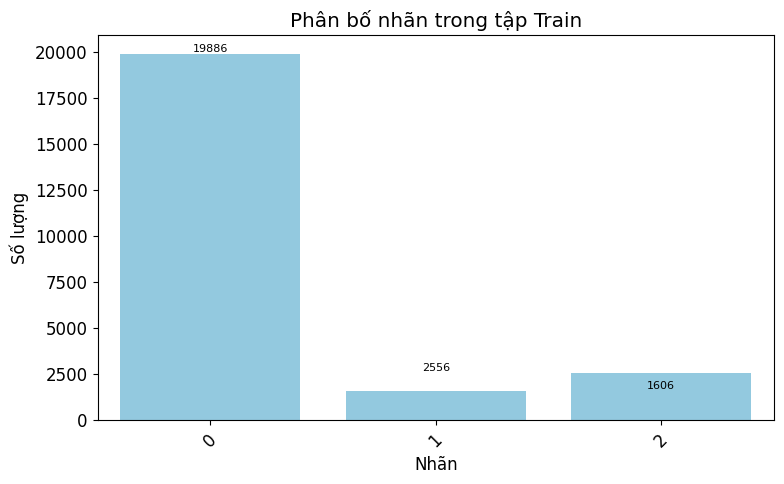

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

if "label_id" in df_train_raw.columns:
    print("=== PHÂN BỐ NHÃN (TRAIN) ===")
    label_counts = df_train_raw["label_id"].value_counts()
    print(label_counts)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(x=label_counts.index, y=label_counts.values, color='skyblue')
    plt.title("Phân bố nhãn trong tập Train")
    plt.xlabel("Nhãn")
    plt.ylabel("Số lượng")
    plt.xticks(rotation=45)

    # Thêm số lượng trên mỗi cột
    for i, v in enumerate(label_counts.values):
        ax.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


In [26]:
# Thống kê độ dài văn bản (số ký tự)
df_train_raw["text_len"] = df_train_raw["free_text"]. astype(str).apply(len)
df_test_raw["text_len"] = df_test_raw["free_text"].astype(str).apply(len)

print("=== THỐNG KÊ ĐỘ DÀI VĂN BẢN (TRAIN) ===")
print(df_train_raw["text_len"].describe())

print("\n=== THỐNG KÊ ĐỘ DÀI VĂN BẢN (TEST) ===")
print(df_test_raw["text_len"].describe())


=== THỐNG KÊ ĐỘ DÀI VĂN BẢN (TRAIN) ===
count    24048.000000
mean        49.283683
std        184.809545
min          1.000000
25%         20.000000
50%         33.000000
75%         56.000000
max      20816.000000
Name: text_len, dtype: float64

=== THỐNG KÊ ĐỘ DÀI VĂN BẢN (TEST) ===
count    6680.000000
mean       48.013772
std        53.581196
min         1.000000
25%        20.000000
50%        33.000000
75%        56.000000
max      1762.000000
Name: text_len, dtype: float64


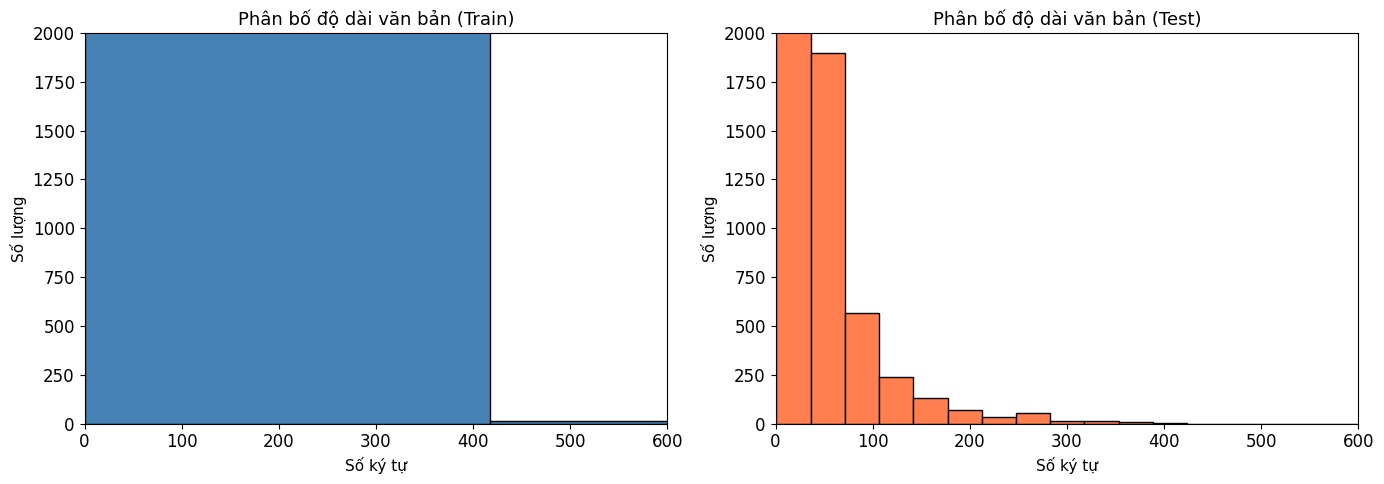

In [35]:
import matplotlib.pyplot as plt

# Tùy chỉnh số bins và giới hạn trục để biểu đồ rõ hơn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train
axes[0].hist(df_train_raw["text_len"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("Phân bố độ dài văn bản (Train)", fontsize=13)
axes[0].set_xlabel("Số ký tự", fontsize=11)
axes[0].set_ylabel("Số lượng", fontsize=11)
axes[0].set_xlim(0, 600)      # Giới hạn độ dài tối đa hiển thị
axes[0].set_ylim(0, 2000)     # Giới hạn số lượng để tránh cột quá cao

# Test
axes[1].hist(df_test_raw["text_len"], bins=50, color="coral", edgecolor="black")
axes[1].set_title("Phân bố độ dài văn bản (Test)", fontsize=13)
axes[1].set_xlabel("Số ký tự", fontsize=11)
axes[1].set_ylabel("Số lượng", fontsize=11)
axes[1].set_xlim(0, 600)
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.show()


In [37]:
# Thống kê số từ (word count)
df_train_raw["word_count"] = df_train_raw["free_text"].astype(str).apply(lambda x: len(x.split()))
df_test_raw["word_count"] = df_test_raw["free_text"].astype(str).apply(lambda x: len(x.split()))

print("=== THỐNG KÊ SỐ TỪ (TRAIN) ===")
print(df_train_raw["word_count"].describe())

print("\n=== THỐNG KÊ SỐ TỪ (TEST) ===")
print(df_test_raw["word_count"].describe())

# %% [13] Xem mẫu theo từng nhãn
if "label" in df_train_raw. columns:
    print("=== MẪU THEO TỪNG NHÃN (TRAIN) ===")
    for label in df_train_raw["label"]. unique():
        print(f"\n--- Nhãn: {label} ---")
        samples = df_train_raw[df_train_raw["label"] == label]["free_text"]. head(3). tolist()
        for i, s in enumerate(samples, 1):
            print(f"  {i}.  {s[:200]}")

=== THỐNG KÊ SỐ TỪ (TRAIN) ===
count    24048.000000
mean        11.507610
std         19.963649
min          1.000000
25%          5.000000
50%          8.000000
75%         13.000000
max       1701.000000
Name: word_count, dtype: float64

=== THỐNG KÊ SỐ TỪ (TEST) ===
count    6680.000000
mean       11.484581
std        12.442907
min         1.000000
25%         5.000000
50%         8.000000
75%        13.000000
max       411.000000
Name: word_count, dtype: float64


In [39]:
# Phát hiện dữ liệu bẩn: URL
def count_urls(text):
    return len(re.findall(r"https?://\S+|www\.\S+", str(text)))

df_train_raw["url_count"] = df_train_raw["free_text"].apply(count_urls)
url_samples = df_train_raw[df_train_raw["url_count"] > 0]
print(f"=== SỐ MẪU CÓ URL: {len(url_samples)} ===")
if len(url_samples) > 0:
    print(url_samples[["free_text", "url_count"]].head(5))

=== SỐ MẪU CÓ URL: 19 ===
                                                                                                                                                                                                    free_text  \
1222                                                                                                           Xem ngay hậu trường cực hiếm của cô Minh Hiếu : https://www.facebook.com/ComeOut.BuocRaAnhSang   
1432                                                                                                                                                     FB chính LinDa: https://www.facebook.com/linda009900   
1839                                                                                                                                                       https://youtu.be/tvyO2B3oEYk thư giãn đã cả nhà ơi   
2020                                                                                                                                      

In [44]:
# Phát hiện dữ liệu bẩn: Mention (@user)
def count_mentions(text):
    return len(re.findall(r"@\w+", str(text)))

df_train_raw["mention_count"] = df_train_raw["free_text"]. apply(count_mentions)
mention_samples = df_train_raw[df_train_raw["mention_count"] > 0]
print(f"=== SỐ MẪU CÓ @MENTION: {len(mention_samples)} ===")
mention_samples[["free_text", "mention_count"]].head(5)

=== SỐ MẪU CÓ @MENTION: 131 ===


,free_text,mention_count
340,@Chiến trần chuẩn 👌,1
341,@Yo Min :)))),1
750,@Linh Kute sao e biết xa giỏi vậy.,1
766,@NGỌC TÂM lúc trước tưởng thật coi.con giờ huy đăng ký kênh luon.éo coi nữa,1
815,@Quynh Anh Nguyen xĩuuuuu,1


In [48]:
#  Phát hiện dữ liệu bẩn: Emoji
def count_emojis(text):
    # Regex đơn giản để tìm emoji unicode
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    return len(emoji_pattern. findall(str(text)))

df_train_raw["emoji_count"] = df_train_raw["free_text"].apply(count_emojis)
emoji_samples = df_train_raw[df_train_raw["emoji_count"] > 0]
print(f"=== SỐ MẪU CÓ EMOJI: {len(emoji_samples)} ===")
emoji_samples[["free_text", "emoji_count"]].sample(5)

=== SỐ MẪU CÓ EMOJI: 2737 ===


,free_text,emoji_count
9091,Minh Anh lúc đầu đọc tên tưởng Kiên lớp mình. 😂,1
22854,Anh Quang be like 😔,1
7249,Con mèo nhà mình thì có sở thích khác các bác ạ 😗,1
7313,đúng rùiiii nekk🙄👀,1
15751,Cực kì là thuyết phục 🙂,1


In [52]:
# Phát hiện teencode phổ biến
TEENCODE_PATTERNS = ["đm", "vl", "vcl", "clgt", "wtf", "lol", "k", "ko", "dc", "đc", "vs", "j", "z"]

def count_teencode(text):
    text_lower = str(text).lower()
    count = 0
    for tc in TEENCODE_PATTERNS:
        # Đếm số lần xuất hiện như từ riêng
        count += len(re.findall(rf"\b{re.escape(tc)}\b", text_lower))
    return count

df_train_raw["teencode_count"] = df_train_raw["free_text"].apply(count_teencode)
teencode_samples = df_train_raw[df_train_raw["teencode_count"] > 0]
print(f"=== SỐ MẪU CÓ TEENCODE: {len(teencode_samples)} ===")
teencode_samples[["free_text", "teencode_count"]]. head(10)

=== SỐ MẪU CÓ TEENCODE: 3617 ===


,free_text,teencode_count
14,Sao t gửi đc bây,1
15,thế đấy. làm j bọn nó. bọn nó có quyền nên làm j chả được :v,2
27,Chương trình quảng cáo xin đc bắt đầu,1
29,Nhậu cái đm chúng mày lũ chó hại dân hại nước,1
31,mài có óc để suy nghĩ ko add? cái đồng băng đó mài tính đào hồ bnhiu cho đủ hả thằng ngu?,1
34,phải thầy k ta,1
43,Gia Lộc Tran Quang còn j vui hơn cà khịa :)))))),1
52,"mẹ, sao bộ k mở cửa hàng kinh doanh bán bình luôn cho dân, ko lại phạt vì mua phải bình đểu :)))",2
53,Cuối cùng anh đã trở lại. Em tưởng anh biến mất luôn cho em mừng 🙂 thiệt là tình( nội dung mang tính giải trí. Ko có ý anti hay ghét ai),1
54,Chi 3 cai gi cung co nhung cai lờ la chi 3 hét kiếp nay cung k bao gio co .,1


In [53]:
# Từ phổ biến nhất (top 30)
def get_all_words(series):
    all_text = " ".join(series. astype(str). tolist())
    words = re.findall(r"\w+", all_text. lower())
    return words

words_train = get_all_words(df_train_raw["free_text"])
word_counts = Counter(words_train)
top_30 = word_counts. most_common(30)

print("=== TOP 30 TỪ PHỔ BIẾN (TRAIN) ===")
for w, c in top_30:
    print(f"  {w}: {c}")

=== TOP 30 TỪ PHỔ BIẾN (TRAIN) ===
  là: 3298
  có: 3137
  mà: 2321
  cho: 2118
  đi: 1995
  thì: 1949
  anh: 1944
  này: 1865
  con: 1650
  của: 1525
  cái: 1495
  người: 1465
  không: 1439
  nó: 1437
  ko: 1431
  rồi: 1406
  em: 1347
  như: 1331
  làm: 1311
  quá: 1299
  cũng: 1274
  nói: 1272
  gì: 1242
  thầy: 1219
  lại: 1129
  ra: 1023
  còn: 1018
  ông: 1015
  hay: 1008
  k: 983


C:\Users\hsvie\AppData\Local\Temp\ipykernel_26132\1830132725.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_list, y=words_list, palette="Blues_d")


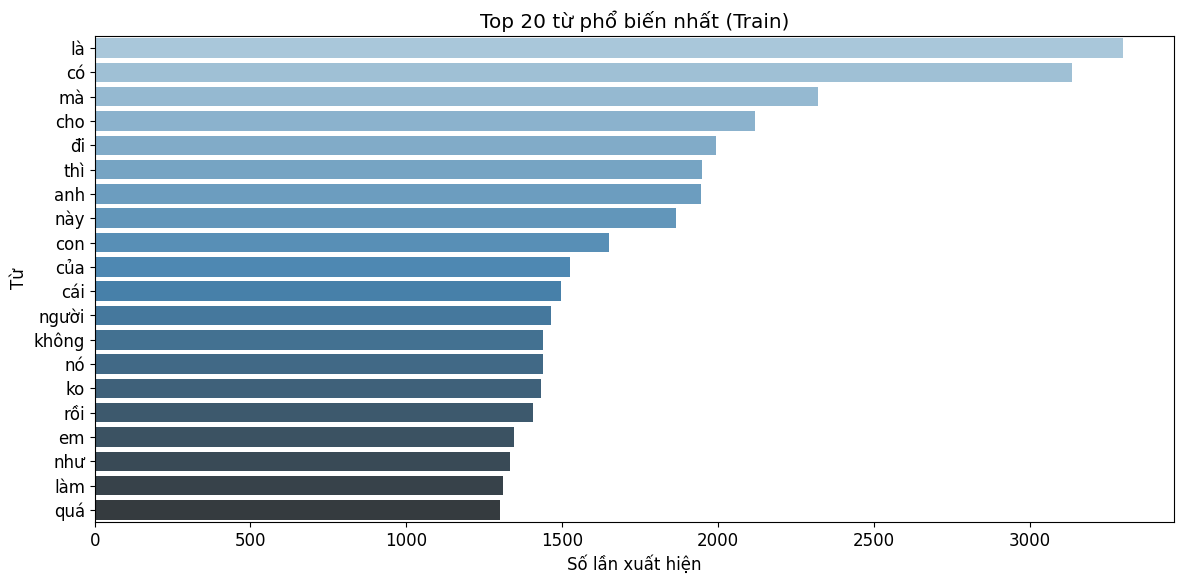

In [54]:
# Biểu đồ top 20 từ phổ biến nhất
top_20 = word_counts.most_common(20)
words_list = [w for w, c in top_20]
counts_list = [c for w, c in top_20]

plt.figure(figsize=(12, 6))
sns.barplot(x=counts_list, y=words_list, palette="Blues_d")
plt.title("Top 20 từ phổ biến nhất (Train)")
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Từ")
plt.tight_layout()
plt.show()

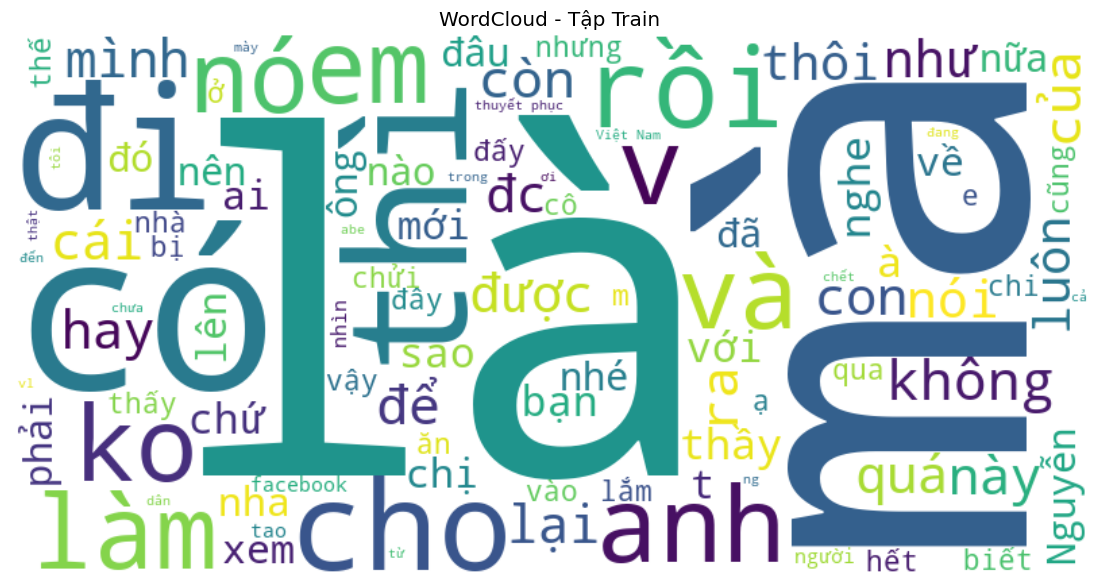

In [55]:
# WordCloud (nếu có thư viện)
try:
    from wordcloud import WordCloud
    
    all_text = " ". join(df_train_raw["free_text"]. astype(str). tolist())
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        max_words=100,
        colormap="viridis"
    ).generate(all_text)
    
    plt. figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("WordCloud - Tập Train")
    plt. tight_layout()
    plt.show()
except ImportError:
    print("⚠️ Chưa cài wordcloud.  Chạy: pip install wordcloud")

In [57]:
# So sánh trước/sau pipeline 

df_train_clean = pd.read_csv(r"D:\Learn\ky1_nam4\Hoc_sau\hate_speech_detection\data\processed\train.csv")
print(f"=== SO SÁNH TRƯỚC/SAU PIPELINE ===")
print(f"Số mẫu thô: {len(df_train_raw)}")
print(f"Số mẫu sạch: {len(df_train_clean)}")
    
    # So sánh vài mẫu
print("\n--- MẪU SO SÁNH ---")
for i in range(min(5, len(df_train_raw))):
    raw_text = str(df_train_raw.iloc[i]["free_text"])
    clean_text = str(df_train_clean.iloc[i]["free_text"])
    if raw_text != clean_text:
        print(f"\n[{i}] THÔ:  {raw_text[:150]}")
        print(f"[{i}] SẠCH: {clean_text[:150]}")


=== SO SÁNH TRƯỚC/SAU PIPELINE ===
Số mẫu thô: 24048
Số mẫu sạch: 24048

--- MẪU SO SÁNH ---

[0] THÔ:  Em được làm fan cứng luôn rồi nè ❤️ reaction quá hay quá cute coi mấy giờ này quá hợp lí =]]]
[0] SẠCH: Em được làm fan cứng luôn rồi nè: red_heart: reaction quá hay quá cute coi mấy giờ này quá hợp lí=]]]

[1] THÔ:  Đúng là bọn mắt híp lò xo thụt :))) bên việt nam t cái này ra cách đây 10 năm r và bọn t gọi là cái L :)))
[1] SẠCH: Đúng là bọn mắt híp lò xo thụt: pacman: ery_happy: bên việt nam tao cái này ra cách đây 10 năm rồi và bọn tao gọi là cái L: pacman: ery_happy:

[4] THÔ:  Từ lý thuyết đến thực hành là cả 1 câu chuyện dài =))
[4] SẠCH: Từ lý thuyết đến thực hành là cả 1 câu chuyện dài: rolling_on_the_floor_laughing:


=== ĐỘ DÀI TRUNG BÌNH THEO NHÃN (TRAIN THÔ) ===
label_id
2    83.776995
0    45.272352
1    44.056040
Name: text_len, dtype: float64


C:\Users\hsvie\AppData\Local\Temp\ipykernel_26132\3861533084.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns. barplot(x=avg_len_by_label.index, y=avg_len_by_label. values, palette="coolwarm")


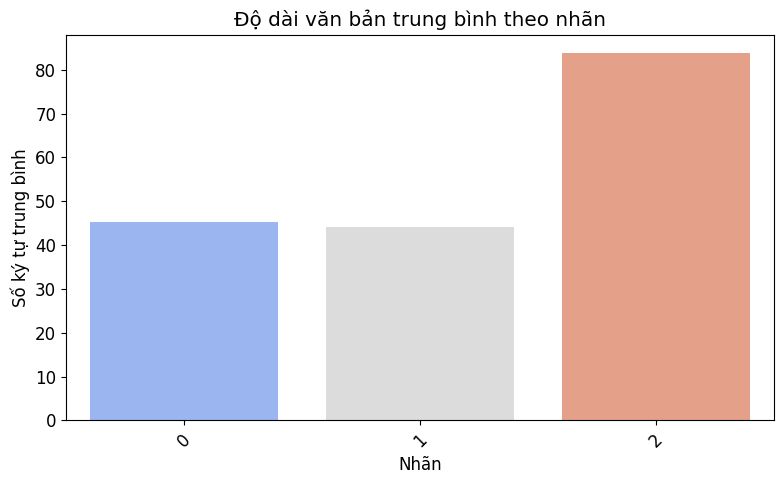

In [60]:
# Phân tích theo nhãn: độ dài trung bình
if "label_id" in df_train_raw.columns:
    print("=== ĐỘ DÀI TRUNG BÌNH THEO NHÃN (TRAIN THÔ) ===")
    avg_len_by_label = df_train_raw.groupby("label_id")["text_len"].mean(). sort_values(ascending=False)
    print(avg_len_by_label)
    
    plt.figure(figsize=(8, 5))
    sns. barplot(x=avg_len_by_label.index, y=avg_len_by_label. values, palette="coolwarm")
    plt.title("Độ dài văn bản trung bình theo nhãn")
    plt.xlabel("Nhãn")
    plt.ylabel("Số ký tự trung bình")
    plt. xticks(rotation=45)
    plt.tight_layout()
    plt.show()

=== SỐ TỪ TRUNG BÌNH THEO NHÃN (TRAIN THÔ) ===
label_id
2    19.969484
1    10.739103
0    10.482048
Name: word_count, dtype: float64


C:\Users\hsvie\AppData\Local\Temp\ipykernel_26132\3456524409.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns. barplot(x=avg_wc_by_label.index, y=avg_wc_by_label. values, palette="coolwarm")


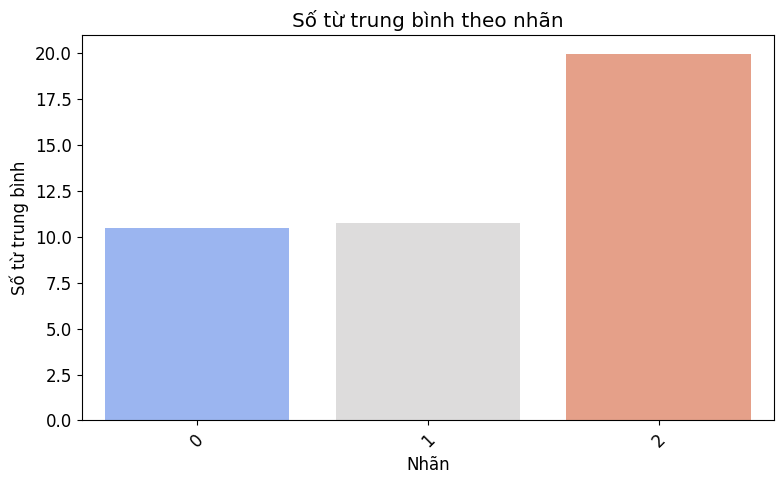

In [63]:
# Phân tích theo nhãn: số từ trung bình
if "label_id" in df_train_raw.columns:
    print("=== SỐ TỪ TRUNG BÌNH THEO NHÃN (TRAIN THÔ) ===")
    avg_wc_by_label = df_train_raw.groupby("label_id")["word_count"].mean().sort_values(ascending=False)
    print(avg_wc_by_label)

plt.figure(figsize=(8, 5))
sns. barplot(x=avg_wc_by_label.index, y=avg_wc_by_label. values, palette="coolwarm")
plt.title("Số từ trung bình theo nhãn")
plt.xlabel("Nhãn")
plt.ylabel("Số từ trung bình")
plt. xticks(rotation=45)
plt.tight_layout()
plt.show()